DSC540-T301 Data Preparation (2265-1)
DSC540 Project Milestone 1

Due on 4/26/2026

Paula Iman

References:

European Social Survey European Research Infrastructure (ESS ERIC) (2025) ESS10 - integrated file, edition 3.3 [Data set]. Sikt - Norwegian Agency for Shared Services in Education and Research. https://doi.org/10.21338/ess10e03_3.

DigitalOcean (2025, June 25). Python open() Function Explained: How to Open, Read, and Write Files. Retrieved March 18, 2026, from https://www.digitalocean.com/community/tutorials/python-read-file-open-write-delete-copy

Lipp, B., Roychowdhury, S., & Sarkar, T. (2020). The data wrangling workshop (2nd ed.). Packt Publishing Ltd. McKinney, W. (2022). Python for data analysis: Data wrangling with pandas, NumPy, and Jupyter (3rd ed.). O'Reilly Media, Inc.

In [110]:
import pandas as pd
import os


In [111]:
# The ESS data is about interview data. The file has over 18,000 rows.
# For the project purposes essential variables are gender, income, satisfaction for demogracy, if elections are perceived free.

# Setting the path for the flatfile downloaded from the ESS Data Portal
folder_path = r'D:\DSC540_Data\BU_Master\DSC540_Data_Preparation'
file_name = 'ESS10e03_3.csv'
full_path = os.path.join(folder_path, file_name)

In [112]:
# Loading the data
# ESS data has variety of characters and may use low_memory settings
# Due to the low_memory settings using low_memory=False
df_ess = pd.read_csv(full_path, low_memory=False)
# Checksing few rows of data
print(f"ESS data has {df_ess.shape[0]} rows and {df_ess.shape[1]} columns.")
df_ess.head(5)

ESS data has 37611 rows and 621 columns.


,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,vinwe,inwde,jinws,jinwe,inwtm,mode,domain,prob,stratum,psu
0,ESS10e03_3,10,3.3,02.12.2025,10038,BE,0.882220,0.972276,0.718075,0.698167,...,2022-09-01 17:47:00,2022-09-01 17:47:00,2022-09-01 17:47:00,2022-09-01 17:47:00,36.0,1,1.0,0.000397,188,2596
1,ESS10e03_3,10,3.3,02.12.2025,10053,BE,1.047643,0.888635,0.718075,0.638107,...,2022-04-08 11:07:00,2022-04-08 11:10:00,2022-04-08 11:07:00,2022-04-08 11:10:00,54.0,2,2.0,0.000334,194,2206
2,ESS10e03_3,10,3.3,02.12.2025,10055,BE,1.087741,0.722811,0.718075,0.519033,...,2022-05-20 11:08:00,2022-05-20 11:10:00,2022-05-20 11:08:00,2022-05-20 11:10:00,77.0,1,2.0,0.000322,198,2114
3,ESS10e03_3,10,3.3,02.12.2025,10062,BE,0.909910,1.005565,0.718075,0.722072,...,2022-05-22 13:58:00,2022-05-22 13:59:00,2022-05-22 13:58:00,2022-05-22 13:59:00,55.0,1,1.0,0.000385,150,2645
4,ESS10e03_3,10,3.3,02.12.2025,10064,BE,0.918949,0.638705,0.718075,0.458639,...,2022-05-18 11:44:00,2022-05-18 11:45:00,2022-05-18 11:44:00,2022-05-18 11:45:00,55.0,1,1.0,0.000381,149,2313


In [113]:
# This data has over 600 columns to choose from,
# I am creating df_subset to choose only columns I am interested int.
# I am tarting with only few columns: Country:'cntry', Gender'gndr', Satisfaction with Democracy:'stfdem', 
# Important that people have equal opportunities'ipeqopt'
# Main source of houshold Income'hinctnta', trust in political parties:'trstprt'
df_subset = df_ess[['cntry', 'gndr', 'stfdem', 'ipeqopt', 'hinctnta', 'trstprt']]
print(f"ESS subset data has {df_subset.shape[0]} rows and {df_subset.shape[1]} columns.")
random_sample = df_subset.sample(n=10)
random_sample

ESS subset data has 37611 rows and 6 columns.


,cntry,gndr,stfdem,ipeqopt,hinctnta,trstprt
34002,PT,2,4,3,6,5
14563,GR,2,2,1,4,2
33066,NO,1,8,3,3,7
18217,HR,1,8,2,77,3
26972,LT,2,2,5,2,0
32124,NO,1,4,2,3,3
31724,NO,1,10,2,6,7
36550,SK,1,7,2,77,3
13296,GB,1,6,2,1,2
35092,SI,2,4,2,3,1


In [114]:
# Printing out how many survey responses each country has recorded.
df_subset['cntry'].value_counts()

GR    2799
BG    2718
IT    2640
CZ    2476
FR    1977
HU    1849
PT    1838
IE    1770
LT    1659
HR    1592
FI    1577
EE    1542
CH    1523
NL    1470
MK    1429
SK    1418
NO    1411
BE    1341
ME    1278
SI    1252
GB    1149
IS     903
Name: cntry, dtype: int64

In [115]:
# Step 1. Renaming the columns into human readable format
df_subset = df_subset.rename(columns={
    'cntry': 'Country',
    'gndr': 'Gender',
    'stfdem': 'Satisfaction with Democracy',
    'ipeqopt': 'Importance of Equality',
    'hinctnta': 'Net Income decile',
    'trstprt': 'Trust in Parties'
})
# Looking at a sample of data from each country with new headers.
df_subset.groupby('Country').sample(1).sort_values('Country')

,Country,Gender,Satisfaction with Democracy,Importance of Equality,Net Income decile,Trust in Parties
1328,BE,2,5,3,5,5
1385,BG,1,4,3,77,3
4469,CH,2,9,1,4,8
7273,CZ,2,4,2,1,1
8455,EE,1,5,3,4,4
10696,FI,2,8,1,5,4
12059,FR,2,88,5,1,1
13788,GB,2,6,4,6,3
16786,GR,1,8,2,5,7
17716,HR,1,7,4,77,2


In [116]:
# Step 2. Creating human readable categorization for the "Gender" column (Mapping)
# Mapping numerical codes to labels
# Run this code only once. After the Gender categorization is changed to text, running the code will give NaN results to Gender.
# If will not see the values anymore.
df_subset['Gender'] = df_subset['Gender'].map({1: 'Male', 2: 'Female', 9:'No Answer'})
# Looking at a sample of data from each country with new headers.
df_subset.groupby('Country').sample(1).sort_values('Country')

,Country,Gender,Satisfaction with Democracy,Importance of Equality,Net Income decile,Trust in Parties
728,BE,Male,7,1,9,6
2938,BG,Female,5,1,6,5
5462,CH,Female,8,1,88,9
7618,CZ,Male,7,3,88,4
8557,EE,Male,5,2,1,0
10667,FI,Male,8,3,88,6
11655,FR,Male,5,1,4,2
13300,GB,Female,7,1,6,4
15315,GR,Male,8,2,6,2
18410,HR,Male,6,2,5,5


In [117]:
# Step 3. Creating "Equality Index" - Feature Engineering
# Combining the Satisfaction with Democracy and Trust in Parties into one inded calculating the average of the two columns
# Creating a combined score - Both columns have scale 1-10
df_subset['System_Satisfaction_Score'] = (df_subset['Satisfaction with Democracy'] + df_subset['Trust in Parties']) /2
random_sample_2 = df_subset.sample(n=5)
random_sample_2

,Country,Gender,Satisfaction with Democracy,Importance of Equality,Net Income decile,Trust in Parties,System_Satisfaction_Score
25252,IT,Male,7,2,2,8,7.5
20311,HU,Male,1,5,88,1,1.0
365,BE,Female,5,1,2,4,4.5
2861,BG,Male,5,2,77,5,5.0
10004,FI,Female,8,1,6,8,8.0


In [118]:
# Step 4. Handling missing values - Data Cleaning
# ESS data uses placeholders in the columns scaled 0-10 and 1-6
# First, we need to find the values used outside of the scale to see how missing data is entered in the table.
print(df_subset['Satisfaction with Democracy'].value_counts().sort_index().tail(4))

10    1083
77      86
88     722
99      57
Name: Satisfaction with Democracy, dtype: int64


In [119]:
print(df_subset['Trust in Parties'].value_counts().sort_index().tail(4))

10    236
77    106
88    469
99     48
Name: Trust in Parties, dtype: int64


In [122]:
print(df_subset['Net Income decile'].value_counts().sort_index().tail(4))

10    2284
77    5836
88    2395
99       8
Name: Net Income decile, dtype: int64


In [123]:
print(df_subset['Importance of Equality'].value_counts().sort_index().tail(4))

6    272
7    146
8    291
9     34
Name: Importance of Equality, dtype: int64


The columns Importance of Equality has score 1-6. The missing values are shown as 7,8,and 9

The other columns use scale 1-10. The missing values are shown as 77, 88, and 99.

In [124]:
# After confirming the place-holder values we can check if there are any missing values
# finding out if there are any place holders like 77,88, or 99 for columns with scale 0-10.
import numpy as np
# creating copy of df_subset to find any place holders
df_clean = df_subset.copy()

# Fixing the Columns with scale 0-10
cols_0_10 = ['Satisfaction with Democracy', 'Trust in Parties', 'Net Income decile']
for col in cols_0_10:
    df_clean[col] = df_clean[col].replace([77, 88, 99], np.nan)
    
# Importance of equality has scale 1-6. Place holders are 7,8, and 9.
df_clean['Importance of Equality'] = df_clean['Importance of Equality'].replace([7, 8, 9], np.nan)

# Adding Gender to replace 'No Answer' with nan
df_clean['Gender'] = df_clean['Gender'].replace(['No Answer'], np.nan)

# Checking if there are any missing values
print(df_clean.isnull().sum())


Country                           0
Gender                            0
Satisfaction with Democracy     865
Importance of Equality          471
Net Income decile              8239
Trust in Parties                623
System_Satisfaction_Score         0
dtype: int64


Note on Data Integrity: Upon verifying the dataset using df_subset, it was confirmed that there were no missing values (NaN) in the Gender column for the selected records. Every participant in this subset successfully identified as either Male or Female. The other categories include NaN values that are handled below.

In [128]:
# Handling the missing data found in the previous steps - the 0-10 scale variable
# First converting the missing value indicators to NaN and then dropping them from the subset.
import numpy as np
columns_to_fix = ['Net Income decile','Satisfaction with Democracy', 'Trust in Parties', 'Importance of Equality']
for col in columns_to_fix:
    df_clean[col] = df_subset[col].replace([77, 88, 99], np.nan)
# Fix the 1-6 scale variable
df_clean['Importance of Equality'] = df_subset['Importance of Equality'].replace([7, 8, 9], np.nan)
# Dropping the rows that have missing data
df_clean = df_clean.dropna()
df_clean.shape

(28331, 7)

Original data had 37611 rows. After dropping the rows with missing values in the subset there are 28331 rows of data left. Most data was moved due to participants giving their income type. 

In [130]:
# Step 5. Aggreagating for Country-level Comparison - Data blending preparation
# The two other data sets intended to use in the project are country level data. 
# The ESS data needs to be transformed from thousands of responses into one country level value.
df_country_averages = df_clean.groupby('Country').agg({
    'Satisfaction with Democracy': 'mean',
    'Net Income decile': 'mean',
    'Trust in Parties': 'mean',
    'Importance of Equality': 'mean',
    'System_Satisfaction_Score': 'mean'
}).reset_index()

# printing the table that can be merged with API and Web data
df_country_averages

,Country,Satisfaction with Democracy,Net Income decile,Trust in Parties,Importance of Equality,System_Satisfaction_Score
0,BE,5.490534,6.067126,4.025818,1.941480,4.758176
1,BG,3.195839,4.976934,2.128449,2.104025,2.662144
2,CH,7.622896,5.712963,5.393939,1.950337,6.508418
3,CZ,5.618018,5.160360,4.022823,2.583784,4.820420
4,EE,5.661654,6.073137,3.827751,2.455229,4.744703
5,FI,7.330182,6.076975,5.487508,1.950709,6.408845
6,FR,5.158730,6.333333,3.412111,1.820694,4.285420
7,GB,5.234756,5.426829,3.497967,1.898374,4.366362
8,GR,5.094822,5.098857,3.441829,2.207128,4.268325
9,HR,4.135985,5.324699,2.308973,2.004625,3.222479


In [131]:
# Step 6. Creating a gender Breakdown Table to show if the interviws were conducted equally with male and female participants.
# This shows the row counts for each gender within each country
gender_counts = df_clean.groupby(['Country', 'Gender']).size().unstack(fill_value=0)

# Renaming columns for clarity
gender_counts = gender_counts.rename(columns={'Male': 'Male_Count', 'Female': 'Female_Count'})

# Displaying the breakdown
gender_counts


Gender,Female_Count,Male_Count
Country,,
BE,570,592
BG,1178,1033
CH,567,621
CZ,953,712
EE,802,661
FI,744,737
FR,846,855
GB,528,456
GR,739,748


In [132]:
# Printing the final human readable data df_clean
df_clean.head(10)

,Country,Gender,Satisfaction with Democracy,Importance of Equality,Net Income decile,Trust in Parties,System_Satisfaction_Score
2,BE,Male,6.0,1.0,7.0,5.0,5.5
3,BE,Male,10.0,2.0,7.0,8.0,9.0
4,BE,Male,5.0,2.0,6.0,6.0,5.5
5,BE,Female,4.0,2.0,6.0,4.0,4.0
6,BE,Female,3.0,1.0,9.0,0.0,1.5
7,BE,Male,4.0,3.0,9.0,3.0,3.5
8,BE,Male,9.0,2.0,5.0,8.0,8.5
9,BE,Male,5.0,2.0,5.0,5.0,5.0
11,BE,Male,6.0,2.0,9.0,2.0,4.0
12,BE,Female,7.0,2.0,5.0,4.0,5.5


### Ethical Analysis of ESS Data Wrangling

In the first milestone, I transformed raw survey data by subsetting variables, renaming headers for readability, and re-coding numeric responses into categorical labels and null values. The data was sourced from the European Social Survey (ESS). ESS is a highly credible, cross-national research project that adheres to the strict guidelines of the General Data Protection Regulation (GDPR). That ensures that data is acquired ethically with informed consent and anonymization.

I made one assumption during the cleaning that responses marked as "Don't know" or "Refusal" as codes 77, 88, and 99 should be treated as NaN. While this prevents the inflation of trust averages, it risks marginalizing the "silent" demographic who may feel unsafe or undecided in their political climate. Furthermore, simplifying gender to a binary "Male/Female" may cause the exclusion of non-binary respondents. However, there were no missing values in the 'Gender' category, showing that all participants had agreed to identify either as "Male" or "Female".

I observed a higher frequency of female respondents across most countries. This indicates a potential participation bias where women were more accessible or willing to engage with the survey. To mitigate this, future steps in this project could involve applying post-stratification weights to ensure that the 'European Insights' accurately represent the total population rather than just the survey participants.

The variable 'hinctnta' was renamed to 'Net Income Decile.' This transformation is critical for the equality analysis as it standardizes household income into ten equal groups (deciles) within each country, allowing for a direct comparison of political trust between the highest and lowest earners regardless of national currency differences.

Adding the Gender analysis and visualization for the participants' gender count in the survey. 

In [135]:
pivot_analysis = df_subset.pivot_table(
    values='Satisfaction with Democracy', 
    index='Country', 
    columns='Gender', 
    aggfunc='mean'
)

pivot_analysis

Gender,Female,Male
Country,,
BE,6.608371,6.116071
BG,4.422594,4.255452
CH,9.807018,8.950128
CZ,7.685755,7.838740
EE,7.771496,6.608947
FI,8.518193,7.880769
FR,7.411765,6.790554
GB,7.379471,5.875494
GR,5.587432,5.323596


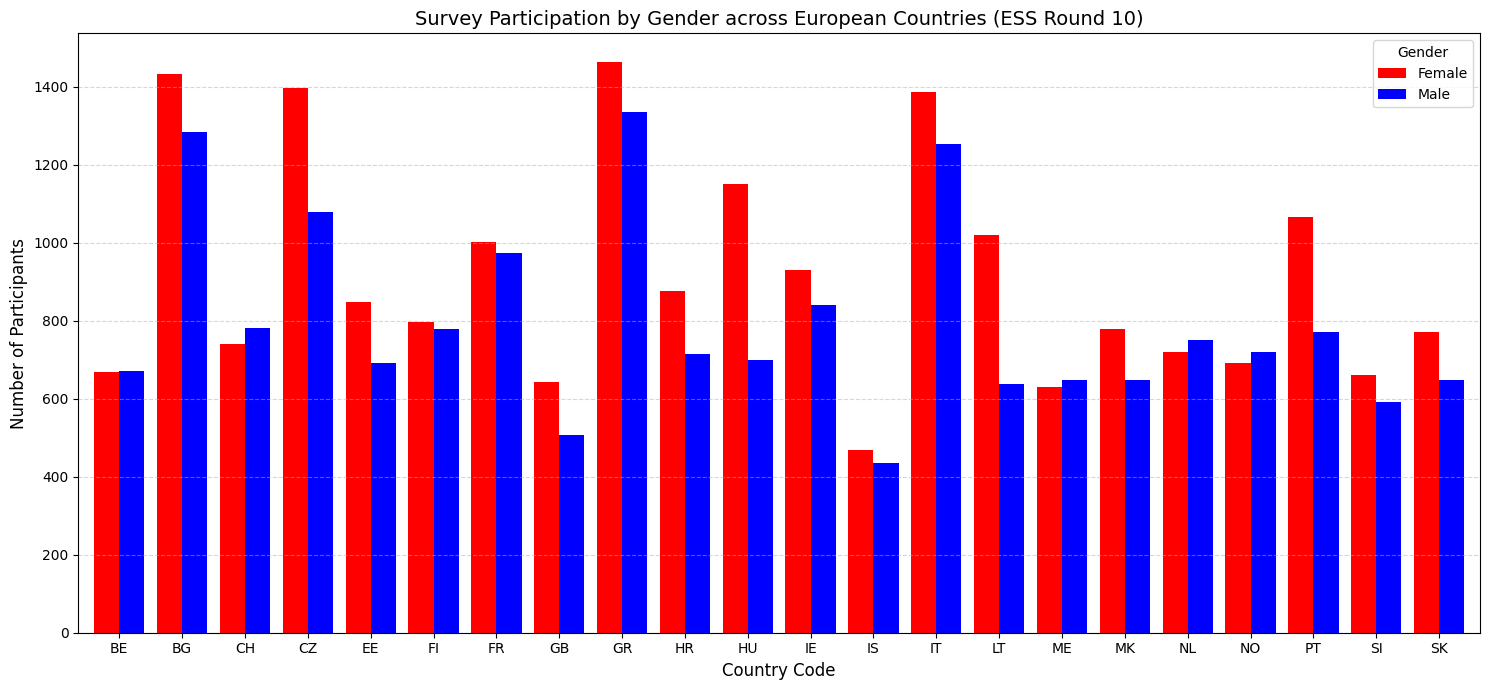

In [136]:
# Creating a plot to show Female and Male participants in the ESS survey.
import matplotlib.pyplot as plt
# Preparing Count of Gender per Country
# Using unstack() to move 'Gender' from a row index to columns (Male/Female)
chart_data = df_subset.groupby(['Country', 'Gender']).size().unstack(fill_value=0)

# Creating the plot
ax = chart_data.plot(kind='bar', figsize=(15, 7), color=['red','blue'], width=0.8)

# Addint titles
plt.title('Survey Participation by Gender across European Countries (ESS Round 10)', fontsize=14)
plt.xlabel('Country Code', fontsize=12)
plt.ylabel('Number of Participants', fontsize=12)
plt.xticks(rotation=0) # trying rotation but the angle was not needed.
plt.legend(title='Gender', labels=['Female', 'Male']) 
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Show the plot
plt.tight_layout()
plt.show()